In [ ]:
import collections
import json
import pickle

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from boilerplate import clip_before, clip_after, clip_at, filter_boilerplate
df = pd.read_csv('mpox_news_data.csv')

In [ ]:
# WARNING: TAKES 5EVER; RERUN AT YOUR OWN RISK
# make a dict of overlaps between articles. 
# overlaps[article1][article2] = the fraction of words in article1 that are shared between it and article2.

overlaps = {i: {j: '' for j in range(len(df['text']))} for i in range(len(df['text']))}

# compute these once, outside the nested for loop
words = {idx: collections.Counter(txt.lower().split()) for idx, txt in enumerate(df['text'])} 
n_words = {idx: len(txt.lower().split()) for idx, txt in enumerate(df['text'])}

for idx1, txt1 in enumerate(df['text']):
    words1 = words[idx1]
    len1 = n_words[idx1]
    if idx1 % 50 == 0:
        print(idx1 / len(df['text']))
    for idx2, txt2 in enumerate(df['text']):
        words2 = words[idx2]
        overlap = words1 & words2
        overlaps[idx1][idx2] = sum([v for v in overlap.values()]) / len1 # not symmetric
#json.dump(overlaps, open('text_overlaps_by_index.json', 'w'))
#pickle.dump(overlaps, open('text_overlaps_by_index.pkl', 'wb'))

0.0
0.012071463061323033
0.024142926122646065
0.036214389183969097
0.04828585224529213
0.06035731530661516
0.07242877836793819
0.08450024142926123
0.09657170449058426
0.1086431675519073
0.12071463061323032
0.13278609367455335
0.14485755673587639
0.15692901979719942
0.16900048285852245
0.1810719459198455
0.19314340898116852
0.20521487204249156
0.2172863351038146
0.22935779816513763
0.24142926122646063
0.2535007242877837
0.2655721873491067
0.27764365041042977
0.28971511347175277
0.30178657653307583
0.31385803959439884
0.32592950265572185
0.3380009657170449
0.3500724287783679
0.362143891839691
0.374215354901014
0.38628681796233705
0.39835828102366005
0.4104297440849831
0.4225012071463061
0.4345726702076292
0.4466441332689522
0.45871559633027525
0.47078705939159826
0.48285852245292127
0.49492998551424433
0.5070014485755674
0.5190729116368904
0.5311443746982134
0.5432158377595364
0.5552873008208595
0.5673587638821825
0.5794302269435055
0.5915016900048286
0.6035731530661517
0.615644616127474

In [7]:
# make article proximity graph
G = nx.DiGraph()
for node1, v in overlaps.items():
    for node2, wt in v.items():
        G.add_edge(node1, node2, weight=wt)

In [10]:
def filter_edge(n1, n2):
    """
    Given 2 nodes (n1, n2) in G, find the word overlap between them. Check if it's above a set threshold.
    """
    return G[n1][n2].get("weight", 0) > 0.95
    
filtered = nx.subgraph_view(G, filter_edge = filter_edge)
comp = nx.strongly_connected_components(filtered) # get SCCs to find chunks of very similar articles
txt_list = list(df['text'])

# print out the very similar articles to read
tot_near_identical = 0
for c in comp:
    if len(c) > 1:
        tot_near_identical += 1
        for node in list(c):
            print(txt_list[node])
            print('-------------')
        print('***********************')
        print()

UK officials say the person who contracted the virus recently traveled from Nigeria.

The person is being treated in London.

The overall risk to the general public is very low, a doctor with the UK Health Security Agency said.

A rare case of monkeypox has been confirmed in England, according to a statement from the UK Health Security Agency.

The agency said the patient recently traveled from Nigeria and that's where they likely contracted it. The individual is being treated at the expert infectious disease unit at the Guy’s and St Thomas’ NHS Foundation Trust in London.

The overall risk to the general public is very low, said Colin Brown, director of clinical and emerging infections at the UK Health Security Agency.

Sir Alimuddin Zumla, a professor of infectious diseases and international health at University College London, told USA TODAY via email that monkeypox is a very rare "but potentially serious viral disease of humans." He said there are two stages of monkeypox symptoms a

In [24]:
tot_near_identical # count chunks of similar articles

2752

In [ ]:
# arguably a dumb way to change the edge threshold but i'm dumb
def filter_edge(n1, n2):
    """
    Given 2 nodes (n1, n2) in G, find the word overlap between them. Check if it's above a threshold
    """
    return G[n1][n2].get("weight", 0) > 0.95

# get indices of articles that are duplicates
filtered = nx.subgraph_view(G, filter_edge=filter_edge)
comp = nx.strongly_connected_components(filtered)
remove = []
for c in comp:
    if len(c) > 1:
        tot_near_identical += 1
        remove.extend(list(c)[1:])           

In [ ]:
# write various dataframes with various levels of aggression for dropping (nearly) identical articles
df_95 = df.drop(remove)
df_95.to_csv('mpox_news_data_95_word_overlap_threshold_for_annotation.csv')

In [ ]:
# removing boilerplate from text
df_95['removed_boilerplate'] = df_95['text'].apply(filter_boilerplate)
df_95['len_original_text'] = df_95['text'].apply(len)
df_95['len_cropped_text'] = df_95['removed_boilerplate'].apply(len)

In [ ]:
# how much text is left over after boilerplate removal?
df_95['frac_retained'] = df_95['len_cropped_text'] / df_95['len_original_text']

Text(0.5, 1.0, 'Boilerplate Removal Impact')

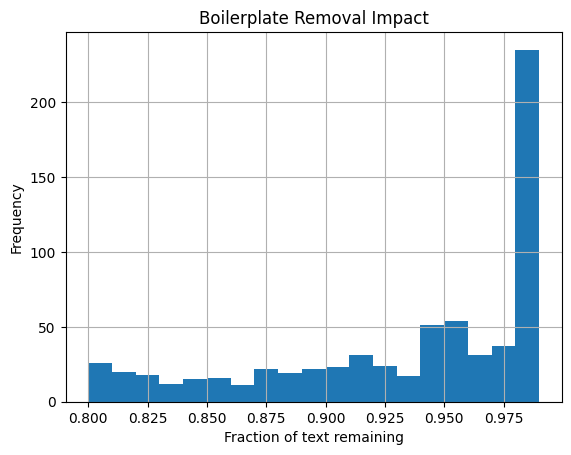

In [ ]:
# distribution of boilerplate removal fractions
df_95['frac_retained'].hist(bins=[0.8 + i / 100 for i in range(20)])
plt.xlabel("Fraction of text remaining")
plt.ylabel("Frequency")
plt.title("Boilerplate Removal Impact")

In [ ]:
len(df_95[df_95['frac_retained'] < 1]) / len(df_95)

0.3247100802854594

In [ ]:
df_95.to_csv('mpox_news_data_95_word_overlap_threshold_for_annotation_boilerplate_removed.csv')